In [96]:
# !pip install qiskit qiskit-aer qiskit-ibm-runtime

In [97]:
import time
import random as rnd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator # for simulating quantum circuits
import pandas as pd
import tqdm

from scipy.optimize import minimize  # for COBYLA

from typing import Literal

# Set seed for reproducibility purposes
seed = 1
rnd.seed(seed)
np.random.seed(seed)


# __Recursive Quantum Approximate Optimization Algorithm (RQAOA)__

## __1 Introduction__

We are given an objective function $C$ composed of $m$ clauses that take as input a bitstring $z$ of length $n$:

$ C(z) = \sum_{\alpha=1}^m C_{\alpha}(z) $

where $z = \overline{z_1 z_2 \dots z_n}$, $z_j \in \{0, 1\}$, and $C_{\alpha}(z) = 1$ if $z$ satisfies $C_{\alpha}$ and $0$ otherwise, with $C_{\alpha}$ typically depending on only a few bits of $z$.

## __2 Max-Cut Problem__

Cost function of _Max-Cut_ :

$C(z) = \sum_{j, k} w_{jk} (1 - z_j z_k)/2$


In [ ]:
class GraphUtils:
    """Various utility functions for graphs"""

    @staticmethod
    def cost_func(graph: nx.Graph, z: list[int]):
        """
        Calculate cost for a partition z of the given graph.
        NOTE: $z \in \{0, 1\}$ instead of $\{-1, +1\}$.
        """
        return sum(w['weight'] for u, v, w in graph.edges(data=True) if z[u] != z[v])

    @staticmethod
    def plot_graph(graph: nx.Graph, node_coloring: list[str] = None, circular = True):
        """Plot the given graph"""
        weights = np.array([w['weight'] for _, _, w in graph.edges(data=True)])
        mean_weight = np.mean(weights)

        # Thickness of an edge is proportional to its weight relative to the mean weight
        plt.figure()
        if circular:
            pos = nx.circular_layout(graph)
        else:
            pos = nx.spring_layout(graph)
        
        nx.draw_networkx_nodes(
            graph,
            pos,
            node_color = node_coloring,
            node_size = 1000,
        )
        nx.draw_networkx_labels(graph, pos)
        nx.draw_networkx_edges(
            graph,
            pos,
            width = weights / mean_weight,
        )
        plt.axis('off')
        plt.show()

    @staticmethod
    def plot_cut(graph: nx.Graph, z: list[int], circular = True) -> None:
        """Plot the partition z of the given graph"""
        coloring = ['y' if zj else 'r' for zj in z]
        GraphUtils.plot_graph(graph, coloring, circular)

    @staticmethod
    def plot_qaoa_results(counts: dict, top_n: int = 20):
        """
        Visualize QAOA measurement results as a bar graph.
        Shows the frequency of the top N measured bitstrings out of 1000 shots.
        """
        # Sort by frequency and take top N
        sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
        bitstrings = [bs for bs, _ in sorted_counts]
        frequencies = [count for _, count in sorted_counts]
        
        # Create bar plot
        plt.figure(figsize=(14, 6))
        bars = plt.bar(range(len(bitstrings)), frequencies, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for i, (bar, freq) in enumerate(zip(bars, frequencies)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                    f'{freq}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.xlabel('Measured Bitstring', fontsize=12, fontweight='bold')
        plt.ylabel('Frequency (out of 1000 shots)', fontsize=12, fontweight='bold')
        plt.title(f'QAOA Measurement Results Distribution - Top {top_n} Outcomes', fontsize=14, fontweight='bold')
        plt.xticks(range(len(bitstrings)), bitstrings, rotation=45, ha='right', fontsize=10)
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.ylim(0, max(frequencies) * 1.15)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def normalize_weights(graph: nx.Graph):
        """Normalize graph weights using Z-score | Min-Max normalization"""

        weights = np.array([w['weight'] for _, _, w in graph.edges(data=True)])

        def min_max_normalization(xs: np.array):
            if xs is None or len(xs) < 2:
                return xs
            return (xs - np.min(xs)) / (np.max(xs) - np.min(xs))

        def z_score_normalization(xs: np.array):
            if xs is None or len(xs) < 2:
                return xs
            return (xs - np.mean(xs)) / np.std(xs)

        weights = z_score_normalization(weights)
        weights = min_max_normalization(weights)

        # NOTE: we add a small constant value to all weights to avoid vanishing circuit parameters
        weights += 0.001

        graph.add_edges_from([
            (u, v, {'weight': w}) for (u, v), w in zip(graph.edges(), weights)
        ])

        return

    @staticmethod
    def add_random_weights(
        graph: nx.Graph, 
        from_distribution: Literal['Uniform', 'Gaussian', 'Exponential'] = None,
        **kwargs,
    ):
        """Add weights to the given graph uniformly at random from the interval [0, 1]"""
        # Initialize random weights
        m = graph.number_of_edges()
        if from_distribution == 'Uniform':
            weights = np.random.uniform(kwargs['low'], kwargs['high'], m)
        elif from_distribution == 'Gaussian':
            weights = np.random.normal(kwargs['mean'], kwargs['sigma'], m)
        elif from_distribution == 'Exponential':
            weights = np.random.exponential(1/kwargs['lambda'], m)
        elif from_distribution is None:
            weights = np.random.random(m)
        else:
            raise ValueError('Unknown distribution')
        # Add weights
        graph.add_edges_from([
            (u, v, {'weight': w}) for (u, v), w in zip(graph.edges(), weights)
        ])
        return

## __Random Assignment__

In [99]:
class RandomAssignment:
    @staticmethod
    def solve(graph: nx.Graph):
        return np.random.randint(0, 2, graph.number_of_nodes())

In [100]:
# Set seed for reproducibility
rnd.seed(seed)
np.random.seed(seed)

graph = nx.complete_graph(10)
GraphUtils.add_random_weights(graph)
GraphUtils.normalize_weights(graph)

random_partition = RandomAssignment.solve(graph)
print('Random-Assignment cost:', GraphUtils.cost_func(graph, random_partition))

Random-Assignment cost: 9.391155376736371


## __3 Brute-Force Method__

While a brute-force approach for solving the Max-Cut problem gives the optimal solution, its running time scales exponentially with the number of nodes in the graph.
Still, the results of this method can be used to analyze the performance of quantum approximation algorithms, such as (Recursive-)QAOA.

In [ ]:
class MaxCutBruteForce:
    """
    Brute-force approach to solve a given 
    graph instance for the Max-Cut problem
    """

    @staticmethod
    def solve(graph: nx.Graph):
        n = graph.number_of_nodes()
        # create list of all n-bit strings
        zs = [list(map(int, format(z, f'0{n}b'))) for z in range(2 ** n)]
        costs = [GraphUtils.cost_func(graph, z) for z in zs]

        cost_max = max(costs)
        zs_max_cut = [z for cost, z in zip(costs, zs) if cost == cost_max]

        # Break ties arbitrarily when returning the max-cut
        return rnd.choice(zs_max_cut)

Max-cut cost: 2.2071038323546595
Max-cut partition: [0, 1, 1, 0, 0]


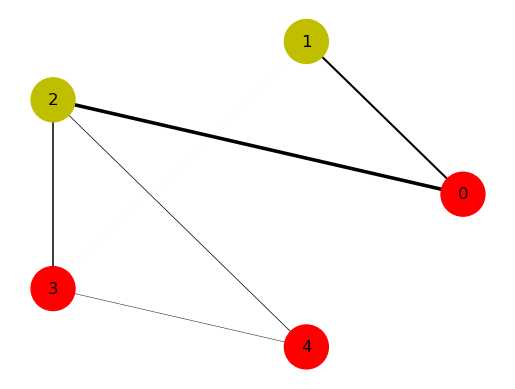

In [102]:
# Set seed for reproducibility
rnd.seed(seed)
np.random.seed(seed)

# alternatively, we can relabel nodes with qubits instead of ints
graph = nx.house_graph()
GraphUtils.add_random_weights(graph)
GraphUtils.normalize_weights(graph)

z_max_cut = MaxCutBruteForce.solve(graph)
cost_max_cut = GraphUtils.cost_func(graph, z_max_cut)

print(f'Max-cut cost: {cost_max_cut}')
print(f'Max-cut partition: {z_max_cut}')
GraphUtils.plot_cut(graph, z_max_cut)


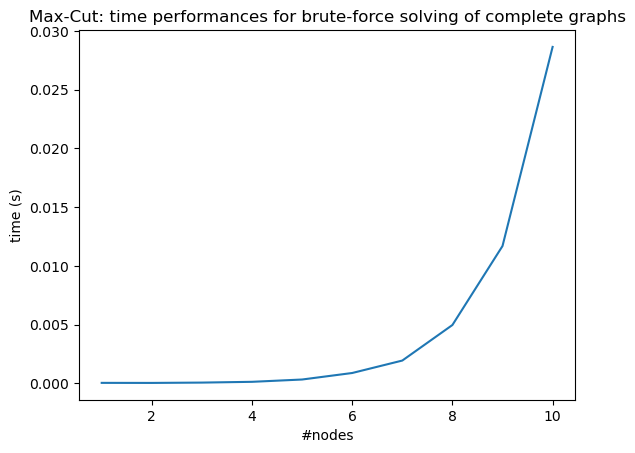

In [103]:
times = []
max_nodes = 10

for num_nodes in range(1, max_nodes + 1):
    graph = nx.complete_graph(num_nodes)
    GraphUtils.add_random_weights(graph)
    GraphUtils.normalize_weights(graph)

    t0 = time.perf_counter()
    z_max_cut = MaxCutBruteForce.solve(graph)
    times.append(time.perf_counter() - t0)

plt.title('Max-Cut: time performances for brute-force solving of complete graphs')
plt.plot(range(1, max_nodes + 1), times)
plt.xlabel('#nodes')
plt.ylabel('time (s)')
plt.show()

## __4 Quantum Approximate Optimization Algorithm (QAOA)__

### __4.1 QAOA Algorithm__

1. __Preparing the initial state and the necessary operators:__

    * Firstly, we prepare the circuit in an equal superposition of all computational basis vectors as the initial state:
    $$ |\psi_0\rangle = \frac{1}{\sqrt{2^n}} \sum_{z = 0}^{2^n - 1} |z\rangle = |+\rangle^{\otimes n} $$

    * We define the _Cost and Mixer Hamiltonians_ for the _Max-Cut_ problem:
    $$ H_C = \sum_{\langle jk \rangle \in E} w_{jk} (1 - \sigma_j^z \sigma_k^z) / 2 $$
    $$ H_M = \sum_{j=1}^n \sigma_j^x $$

    * Alternatively, we can define the _Ising-like_ Cost Hamiltonian (the first term is disregarded in the implementation):
    $$ H_C = \sum_{j} \omega_j \sigma_j^z + \sum_{\langle jk \rangle \in E} J_{jk} \cdot \sigma_j^z \sigma_k^z $$

    * For these Hamiltonians, we state the corresponding parametrized evolution operators:
    $$ U_C(\gamma_l) = e^{- i \gamma_l H_C} = e^{- i \gamma_l \sum_{\langle jk \rangle \in E} w_{jk} (1 - \sigma_j^z \sigma_k^z) / 2} \equiv \prod_{\langle jk \rangle \in E} e^{- i \gamma_l w_{jk} \sigma_j^z \sigma_k^z} $$
    $$ U_M(\beta_l)  = e^{- i \beta_l H_M} = \prod_{j=1}^n e^{- i \beta_l \sigma_j^x} $$

    where $\gamma_l, \beta_l \in \{0, 2\pi\}$ represent the parameters.

    * Essentially, the goal of the QAOA circuit is to find the ground state of $H_C$:

    $$ |\psi_0\rangle = \argmin_{|\psi\rangle} \langle\psi|H_C|\psi\rangle $$

2. __Building the circuit:__

    * The depth-$p$ QAOA circuit is parametrized by two vectors $\mathbf{\gamma} = [\gamma_0, \gamma_1, \dots, \gamma_{p-1}]$ and $\mathbf{\beta} = [\beta_0, \beta_1, \dots, \beta_{p-1}]$.

    * For a given QAOA depth $p \ge 1$, we apply the block of operators $U_M(\gamma_l) U_C(\beta_l)$ $p$ times, sequentially, with $l \in \{0, 1, \dots, p-1\}$. This will result in the final state:
    $$ |\psi(\gamma, \beta)\rangle = \prod_{l=0}^{p-1} U_M(\gamma_l) U_C(\beta_l) |\psi_0\rangle $$


3. __Computing the cost:__
    * For each edge $\langle jk \rangle$, compute the $\langle\sigma_j^z \sigma_k^z \rangle = \langle\psi(\mathbf{\gamma}, \mathbf{\beta})| \sigma_j^z \sigma_k^z |\psi(\mathbf{\gamma}, \mathbf{\beta})\rangle$ correlation.

    * QAOA cost is computed as the expectation value of $H_C$:
    $$ 
    F_p(\mathbf{\gamma}, \mathbf{\beta}) 
        = \langle H_C \rangle 
        = \langle\psi(\mathbf{\gamma}, \mathbf{\beta})| H_C |\psi(\mathbf{\gamma}, \mathbf{\beta})\rangle 
        \equiv - \sum_{\langle jk \rangle \in E} w_{jk} \langle\sigma_j^z \sigma_k^z \rangle 
        \equiv - \sum_{\langle jk \rangle \in E} w_{jk} \langle\psi(\mathbf{\gamma}, \mathbf{\beta})| \sigma_j^z \sigma_k^z |\psi(\mathbf{\gamma}, \mathbf{\beta})\rangle
    $$



4. __Optimization step:__
    * Before estimating the optimal partition, QAOA needs find the optimal parameter set which maximizes $F_p$:
        $$ M_p = \max_{\mathbf{\gamma},\mathbf{\beta}} F_p(\mathbf{\gamma}, \mathbf{\beta})$$

    * The key insight is that for large QAOA depth $p$, $M_p$ converges to the max cost, $C_{max}$, as $M_p \ge M_{p-1}$ and:
        $$ \lim_{p \rightarrow \infty} M_p = C_{max}$$

    * The original QAOA paper presents a classical formula to compute $F_p$ for given $(\mathbf{\gamma}, \mathbf{\beta})$ when depth $p = 1$. However, in our implementation, we made use of a classical optimizer to estimate the optimal parameter set.

    * __COBYLA__:
        * According to scipy documentation:
            > Method COBYLA uses the Constrained Optimization BY Linear Approximation (COBYLA) method [9], [10], [11]. The algorithm is based on linear approximations to the objective function and each constraint. The method wraps a FORTRAN implementation of the algorithm. [...]
    
        * COBYLA takes as input an objective function, an initial guess of the parameter set, and a restiction on the interval of values for the parameters.
        Its output is an estimation of the optimal set of parameters.

5. __Extracting the solution:__
    * Using the estimated optimal set of parameters, we take several samples from the QAOA circuit.
    * We compute the cost for each sample representing a graph partition.
    * Finally, we pick the one with the maximum cost as the estimated optimal partition of the graph. 

### __4.2 QAOA Implementation__

In [ ]:
class QAOA:
    """QAOA algorithm implementation for the Ising-like cost Hamiltonian problem"""

    def __init__(self, 
        graph: nx.Graph, 
        depth: int,
        repetitions: int,
    ):  
        # Initialize the QAOA circuit of given depth
        circuit, qubits, gammas, betas = \
            self.create_qaoa_circuit(graph, depth)

        self.graph   = graph
        self.depth   = depth
        self.qubits  = qubits
        self.circuit = circuit
        self.gammas  = gammas
        self.betas   = betas
        self.repetitions = repetitions


    @staticmethod
    def create_qaoa_circuit(
        graph: nx.Graph, 
        depth: int,
    ):
        """
        Create the QAOA circuit of given depth for the specified graph instance

        Args:
            graph (nx.Graph): graph data structure for a certain Max-Cut problem instance
            depth (int): depth of qaoa circuit

        Returns:
            QAOA circuit, qubits, and gamma and beta parameters
        """
        n_qubits = graph.number_of_nodes()
        
        # Create quantum and classical registers
        qreg = QuantumRegister(n_qubits, 'q')
        creg = ClassicalRegister(n_qubits, 'c')
        circuit = QuantumCircuit(qreg, creg)
        
        # Create parameter objects
        gammas = [Parameter(f'gamma{_}') for _ in range(depth)]
        betas = [Parameter(f'beta{_}') for _ in range(depth)]
        
        # Apply Hadamard gates to all qubits
        for i in range(n_qubits):
            circuit.h(qreg[i])

        edges = list(graph.edges(data=True))

        for k in range(depth):
            # Evolution operator for Cost Hamiltonian
            for u, v, w in edges:
                angle = gammas[k] * w['weight']
                circuit.rzz(angle, qreg[u], qreg[v])

            # Evolution operator for Mixer Hamiltonian
            for i in range(n_qubits):
                circuit.rx(betas[k], qreg[i])

        # Measure all qubits
        for i in range(n_qubits):
            circuit.measure(qreg[i], creg[i])

        # Return circuit, qubits, and parameters
        return circuit, list(range(n_qubits)), gammas, betas


    def run_circuit(self, param_values, repetitions: int = None):
        """Run the QAOA circuit with the given parameter values for the $\gamma$'s and $\beta$'s."""
        if repetitions is None:
            repetitions = self.repetitions
        
        # Create parameter binding dictionary
        param_dict = {}
        for i, gamma_param in enumerate(self.gammas):
            param_dict[gamma_param] = param_values[i]
        for i, beta_param in enumerate(self.betas):
            param_dict[beta_param] = param_values[len(self.gammas) + i]
        
        # Bind the parameters to the circuit
        bound_circuit = self.circuit.assign_parameters(param_dict)
        
        # Run the circuit with AerSimulator
        simulator = AerSimulator()
        result = simulator.run(bound_circuit, shots=repetitions).result()
        counts = result.get_counts(0)
        
        # Convert counts to results format compatible with the rest of the code
        return [QiskitResultWrapper(counts)]
    
    
    def estimate_cost(self, counts: dict):
        """
        Estimate the cost function of the QAOA (i.e., $\langleH_C\rangle$) 
        on the given graph using the provided computational basis bitstrings.
        """
        cost_value = 0.0
        total_shots = sum(counts.values())
        
        for bitstring, count in counts.items():
            z = [int(bit) for bit in bitstring]
            cost = GraphUtils.cost_func(self.graph, z)
            cost_value += cost * count / total_shots
        
        return cost_value
    

    def estimate_costs(self, results: list):
        """Estimate costs for multiple results"""
        return np.array([
            self.estimate_cost(result.counts) 
            for result in results
        ])
    

    def get_estimated_max_cut_partition(self, optimal_params, repetitions: int = None):
        """
        NOTE: even though it finds some max cut partition, it does 
        not give a good view of the estimated average max cost.
        """
        if repetitions is None:
            repetitions = self.repetitions
        
        # Create parameter binding dictionary
        param_dict = {}
        for i, gamma_param in enumerate(self.gammas):
            param_dict[gamma_param] = optimal_params[i]
        for i, beta_param in enumerate(self.betas):
            param_dict[beta_param] = optimal_params[len(self.gammas) + i]
        
        # Bind and run circuit
        bound_circuit = self.circuit.assign_parameters(param_dict)
        simulator = AerSimulator()
        result = simulator.run(bound_circuit, shots=repetitions).result()
        counts = result.get_counts(0)

        # Find the bitstring with maximum cost
        z_max_cost = None
        max_cost = -1
        for bitstring, count in counts.items():
            z = [int(bit) for bit in bitstring]
            cost = GraphUtils.cost_func(self.graph, z)
            if cost > max_cost:
                max_cost = cost
                z_max_cost = z
        
        return z_max_cost
    

    def get_avg_max_cost(self, optimal_params, repetitions: int = None):
        if repetitions is None:
            repetitions = self.repetitions
        
        # Create parameter binding dictionary
        param_dict = {}
        for i, gamma_param in enumerate(self.gammas):
            param_dict[gamma_param] = optimal_params[i]
        for i, beta_param in enumerate(self.betas):
            param_dict[beta_param] = optimal_params[len(self.gammas) + i]
        
        # Bind and run circuit
        bound_circuit = self.circuit.assign_parameters(param_dict)
        simulator = AerSimulator()
        result = simulator.run(bound_circuit, shots=repetitions).result()
        counts = result.get_counts(0)

        # Compute average cost
        avg_cost = 0.0
        total_shots = sum(counts.values())
        for bitstring, count in counts.items():
            z = [int(bit) for bit in bitstring]
            cost = GraphUtils.cost_func(self.graph, z)
            avg_cost += cost * count / total_shots
        
        return avg_cost


class QiskitResultWrapper:
    """Wrapper class to make Qiskit results compatible with rest of code"""
    def __init__(self, counts):
        self.counts = counts
        self.data = pd.DataFrame([(bitstring, count) for bitstring, count in counts.items()], 
                                  columns=['bitstring', 'count'])

### __4.3 QAOA Optimizer__

In [ ]:

class QAOA_Optimizer:
    """Base abstract class for QAOA optimizers."""
    def optimize(self, qaoa: QAOA):
        raise NotImplementedError()
    

class COBYLA_Optimizer(QAOA_Optimizer):
    """COBYLA optimizer for QAOA circuit parameters"""
    def __init__(self,
        initial_guess: np.ndarray,
        min_val: float,
        max_val: float,
        max_iter: int,
    ):
        self.initial_guess = initial_guess
        self.min_val = min_val
        self.max_val = max_val
        self.max_iter = max_iter

    @staticmethod
    def build_objective_func(qaoa: QAOA):
        """Build objective function for COBYLA"""
        def objective_func(xs):
            # Run circuit and estimate costs
            results = qaoa.run_circuit(xs)
            estimated_costs = qaoa.estimate_costs(results)
            
            # Multiply by -1 because scipy.minimize(method='COBYLA') 
            # is minimizing (and we want to maximize the cost)
            return (-1) * estimated_costs[0]
        
        return objective_func

    def optimize(self, qaoa: QAOA):
        # Define the objective function
        objective_func = self.build_objective_func(qaoa)

        # Define the constraints for parameter bounds
        bounds = [(self.min_val, self.max_val) for _ in range(len(self.initial_guess))]
    
        # Define further options for the COBYLA
        options = {
            'maxiter': self.max_iter,
            'disp': True,
        }

        # Solve the optimization problem using scipy.minimize
        optimiz_res = minimize(
            objective_func,
            self.initial_guess, 
            method='COBYLA',
            options=options,
        )
    
        # Return the optimal parameter set
        optimal_params = optimiz_res.x
        return optimal_params
    
    # Make the optimizer callable
    __call__ = optimize

## __5 Recursive QAOA (RQAOA)__

### RQAOA Implementation

In [ ]:
class RQAOA:
    """Recursive Quantum Approximate Optimization Algorithm"""
    def __init__(self,
        qaoa_depth: int,
        qaoa_repetitions: int,
        qaoa_optimizer: QAOA_Optimizer,
        target_num_nodes: int,
    ):
        self.qaoa_depth       = qaoa_depth
        self.qaoa_repetitions = qaoa_repetitions
        self.qaoa_optimizer   = qaoa_optimizer
        self.target_num_nodes = target_num_nodes


    @staticmethod
    def _reduce_graph(
        curr_graph: nx.Graph,
        i: int, j: int, s: int,
    ):
        """
        Build the reduced graph with node i as the merged node,
        with node j eliminated, and with s = sign(M_ij).
        """
        WEIGHT = 'weight'
        W_DEFAULT = {WEIGHT: 0}

        new_edges = []
        for p, q, w in curr_graph.edges(data=True):
            if p == j:
                if q not in {i, j}:
                    w_old = curr_graph.get_edge_data(i, q, W_DEFAULT)
                    w_new = {WEIGHT: w_old[WEIGHT] + s * w[WEIGHT]}  # merge edges
                    new_edges.append((i, q, w_new))
            elif q == j:
                if p not in {i, j}:
                    w_old = curr_graph.get_edge_data(p, i, W_DEFAULT)
                    w_new = {WEIGHT: w_old[WEIGHT] + s * w[WEIGHT]}  # merge edges
                    new_edges.append((p, i, w_new))
            else:
                new_edges.append((p, q, w))

        return nx.Graph(new_edges)
    

    @staticmethod
    def _relabel_nodes(graph: nx.Graph):
        """
        Relabel graph nodes in increasing order of their old labels
        with new labels ranging from 0 to |V| - 1.
        """
        mapping = dict(zip(sorted(graph.nodes()), range(graph.number_of_nodes())))
        return nx.relabel_nodes(graph, mapping, copy=True)


    @staticmethod
    def _compute_cut_partition(saved_vars, cut_partition):
        """
        Retrace the variables saved after each variable elimination step
        to compute the partition as estimated by RQAOA.
        """
        # Retrace the variables from each elimination step (i, j, sign(M_ij))
        for i, j, s in reversed(saved_vars):
            cut_partition.insert(min(i, j), cut_partition[max(i, j) - 1] ^ (s == -1))
            # BUG: not sure if this is the right way to retrace the saved variables

        return cut_partition
    

    @staticmethod
    def _compute_local_correlations(
        graph: nx.Graph, 
        qaoa: QAOA, 
        counts: dict
    ):
        """
        Compute local <ZZ> correlations for each edge in the given graph.
        
        The RQAOA algorithm needs to decide which variable (qubit) to eliminate next.
        This decision is based on the strength of correlations between qubits, as 
        estimated from the QAOA measurements.
        
        For each edge {u, v}, we compute the expectation value:
            M_uv = E[Z_u * Z_v] = <Z_u Z_v>
        
        This is estimated from the measurement outcomes (bitstrings) of 1000 shots:
        - For each measured bitstring, we extract the bits at positions u and v
        - Convert bits (0, 1) to Pauli Z eigenvalues (+1, -1) respectively
        - Compute the product: (+1) * (+1) = 1 for same, (-1) * (+1) = -1 for different
        - Average this product across all 1000 measurement outcomes
        
        The correlation M_uv indicates:
        - M_uv > 0: qubits u and v tend to have the SAME value (correlated)
        - M_uv < 0: qubits u and v tend to have DIFFERENT values (anti-correlated)
        - |M_uv| close to 1: strong correlation
        - |M_uv| close to 0: weak/no correlation
        
        RQAOA then eliminates the edge with the strongest correlation (largest |M_uv|),
        merging the two qubits into one (fixing their relationship based on sign of M_uv).
        """
        ms = []  # list of local correlations for each edge
        total_shots = sum(counts.values())
        
        for u, v, w in graph.edges(data=True):
            correlation = 0.0
            for bitstring, count in counts.items():
                # Extract bits for qubits u and v
                # NOTE: In Qiskit, bitstring indices are in reverse order (LSB at index 0)
                u_bit = int(bitstring[u])
                v_bit = int(bitstring[v])
                
                # Convert bits to Pauli Z eigenvalues: 0 -> +1, 1 -> -1
                # This is because Z|0> = +|0>, Z|1> = -|1>
                u_sign = (-1) ** u_bit  # 0 -> +1, 1 -> -1
                v_sign = (-1) ** v_bit  # 0 -> +1, 1 -> -1
                
                # Accumulate the product of eigenvalues, weighted by measurement frequency
                correlation += (u_sign * v_sign) * count / total_shots
            
            ms.append(correlation)
        return ms


    def eliminate_variable(self, curr_graph: nx.Graph):
        """Eliminate-Variable subroutine of RQAOA"""
        # QAOA step
        qaoa = QAOA(
            curr_graph,
            self.qaoa_depth,
            self.qaoa_repetitions,
        )

        # QAOA optimization
        optimal_params = self.qaoa_optimizer.optimize(qaoa)

        # Run the circuit to get measurement results
        results = qaoa.run_circuit(optimal_params)
        assert len(results) == 1
        counts = results[0].counts

        # Estimate the local correlation M_e = <ZZ> for each edge e = {u,v}
        ms = RQAOA._compute_local_correlations(curr_graph, qaoa, counts)

        # Find edge and node to be eliminated
        f = np.argmax(np.abs(ms))           # index of maximum local correlation M_ij
        e = list(curr_graph.edges())[f]     # edge {i,j} corresponding to M_ij
        i = max(e)                          # i is the node to be merged
        j = min(e)                          # j is the node to be eliminated
        s = np.sign(ms[f])                  # sign(M_ij): {u,v} correlated if s > 0 and anti-correlated if s < 0

        # Build the reduced graph with node i as the merged node and node j eliminated
        reduced_graph = RQAOA._reduce_graph(curr_graph, i, j, s)
        reduced_graph = RQAOA._relabel_nodes(reduced_graph)

        return i, j, s, reduced_graph


    def solve(self,
        init_graph: nx.Graph,
    ):
        """Solve the given graph instance of a Max-Cut problem using RQAOA"""
        curr_graph = init_graph
        saved_vars = []  # save (i, j, sign(M_ij)) after each elimination step

        # RQAOA variable elimination loop
        for _ in range(init_graph.number_of_nodes() - self.target_num_nodes):
            i, j, s, curr_graph = self.eliminate_variable(curr_graph)
            saved_vars.append((i, j, s))

        reduced_graph = curr_graph

        # Solve the reduced graph using a classical brute force method
        cut_partition = MaxCutBruteForce.solve(reduced_graph)

        # Compute the cut partition as estimated by RQAOA
        cut_partition = RQAOA._compute_cut_partition(
            saved_vars,
            cut_partition 
        )

        return cut_partition

## __6 Experiments__

* QAOA experiment methodology:
    * we run QAOA with depth p, where p in {1, 2, 3, 4};
    * number of circuit samples (repetitions) on each run is set to 1000;
    * we will use the COBYLA optimizer;
    * initial guess for COBYLA is set to all zeros;
    * interval for COBYLA is set to [0, 1];
    * we compute the optimal cost and the QAOA average estimated cost (taken from 1000 circuit samples) and show the approx. ratios of these results;
    * we will run both QAOA and RQAOA on several graph instances as will be defined below.

* RQAOA experiment methodology:
    * same depths, repetitions, and optimizer setting as for QAOA;

* Prepare code to run experiments with QAOA and RQAOA

In [107]:
def run_qaoa_experiment(
    graph: nx.Graph, 
    qaoa_optimizer: str = 'COBYLA',
    qaoa_depth: int = 2,
    qaoa_repetitions: int = 1000,
    **kwargs,
):
    # Initialize the QAOA algorithm
    qaoa = QAOA(
        graph,
        qaoa_depth,
        qaoa_repetitions,
    )

    optimizer = COBYLA_Optimizer(
        initial_guess = np.array([0] * qaoa.depth * 2),  # FIXME: COBYLA initial guess is not supposed to be hardcoded!
        min_val = 0.0,
        max_val = 1.0,
        max_iter = 1000,
    )

    # Get the estimated optimal parameters
    optimal_params = optimizer.optimize(qaoa)

    # Run circuit with optimal parameters to get measurement outcomes
    results = qaoa.run_circuit(optimal_params)
    assert len(results) == 1
    counts = results[0].counts

    # Compute the optimal partition using Brute-Force
    optimal_partition = MaxCutBruteForce.solve(graph)

    # Compute optimal cost and QAOA estimated cost
    optimal_cost = GraphUtils.cost_func(graph, optimal_partition)
    avg_estimated_cost = qaoa.get_avg_max_cost(optimal_params)

    return optimal_cost, avg_estimated_cost, counts


def run_qaoa_experiment_on_graphs(
    graphs: list[nx.Graph],
    max_samples = 10,
    qaoa_depth=1,
    qaoa_repetitions=1000,
):
    data = []
    try:
        for name, graph in tqdm.tqdm(graphs.items()):
            samples = []
            for _ in range(max_samples):
                # Add random weights to each graph
                GraphUtils.add_random_weights(graph)
                GraphUtils.normalize_weights(graph)

                # Run QAOA (unpack only the costs, ignore counts)
                optimal_cost, estimated_cost, _ = run_qaoa_experiment(
                    graph=graph,
                    qaoa_depth=qaoa_depth,
                    qaoa_repetitions=qaoa_repetitions,
                    qaoa_optimizer='COBYLA',
                )

                # Save results
                samples.append((optimal_cost, estimated_cost))

            data.append(samples)
    except Exception | ValueError as e:
        print(e)
    except:
        print('Unknown error')
    finally:
        return np.array(data)

In [108]:
def run_rqaoa_experiment(
    graph: nx.Graph, 
    qaoa_depth = 2, 
    qaoa_repetitions = 1000,
    target_num_nodes=2,
):
    # Set QAOA circuit parameters
    pass

    # Set QAOA optimizer
    qaoa_optimizer = COBYLA_Optimizer(
        initial_guess = np.array([0.0] * 2 * qaoa_depth),
        min_val = 0,
        max_val = 1,
        max_iter = 1000,
    )

    # Initialize RQAOA algorithm
    rqaoa = RQAOA(
        qaoa_depth=qaoa_depth,
        qaoa_repetitions=qaoa_repetitions,
        qaoa_optimizer=qaoa_optimizer,
        target_num_nodes=target_num_nodes,
    )

    # Solve using RQAOA
    rqaoa_partition = rqaoa.solve(
        init_graph=graph, 
    )

    # Compute the optimal partition using Brute-Force
    optimal_partition = MaxCutBruteForce.solve(graph)

    optimal_cost = GraphUtils.cost_func(graph, optimal_partition)
    estimated_cost = GraphUtils.cost_func(graph, rqaoa_partition)

    return optimal_cost, estimated_cost


def run_rqaoa_experiment_on_graphs(
    graphs: list[nx.Graph], 
    max_samples = 10,
    qaoa_depth=1,
    qaoa_repetitions=1000,
    target_num_nodes=2,
):
    data = []
    try:
        for name, graph in tqdm.tqdm(graphs.items()):
            samples = []
            for _ in range(max_samples):
                # Add random weights to each graph
                GraphUtils.add_random_weights(graph)
                GraphUtils.normalize_weights(graph)

                # Run RQAOA
                optimal_cost, estimated_cost = run_rqaoa_experiment(
                    graph=graph,
                    qaoa_depth=qaoa_depth,
                    qaoa_repetitions=qaoa_repetitions,
                    target_num_nodes=target_num_nodes
                )

                # Save results
                samples.append((optimal_cost, estimated_cost))

            data.append(samples)
    except Exception | ValueError as e:
        print(e)
    except:
        print('Unknown error')
    finally:  # Salvage data generated until the last iteration
        return np.array(data)

* Examples of running QAOA and RQAOA experiments:


   Normal return from subroutine COBYLA

   NFVALS =   44   F =-1.336812E+00    MAXCV = 0.000000E+00
   X = 1.059942E+00  -5.799606E-02  -4.705680E-01  -2.942087E-01

   Normal return from subroutine COBYLA

   NFVALS =   52   F =-1.324924E+00    MAXCV = 0.000000E+00
   X =-1.967041E-02   1.213104E+00  -1.677762E+00  -5.692618E-01

   Normal return from subroutine COBYLA

   NFVALS =   48   F =-3.192637E-01    MAXCV = 0.000000E+00
   X = 1.267132E+00   1.409595E-02  -9.550338E-02  -5.304349E-01

   Normal return from subroutine COBYLA

   NFVALS =   47   F =-3.594695E-01    MAXCV = 0.000000E+00
   X = 2.350713E-01  -1.650365E-01  -2.178727E-01  -8.908433E-02


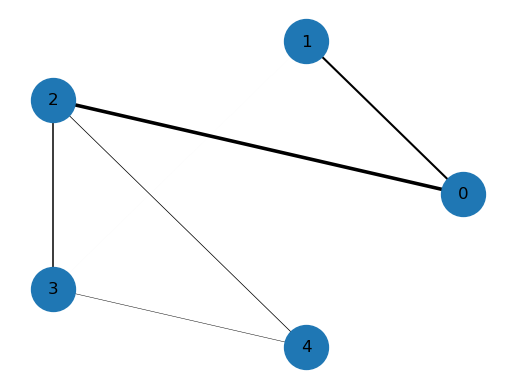

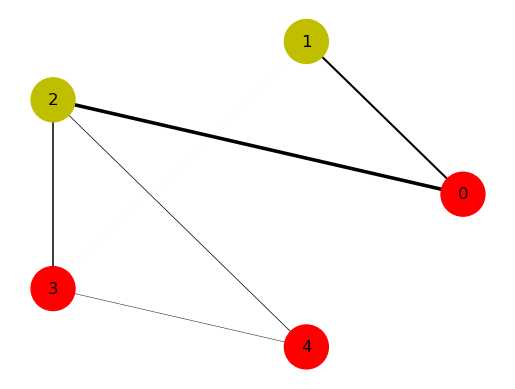

Brute-Force optimal partition: [0, 1, 1, 0, 0]
Brute-Force optimal max cost: 2.2071038323546595
QAOA estimated average max cost: 1.2943037262006478
RQAOA estimated max cut cost: 1.9145306199926762
Approximation ratio for QAOA: 58.6%
Approximation ratio for RQAOA: 86.7%


<Figure size 1200x500 with 0 Axes>

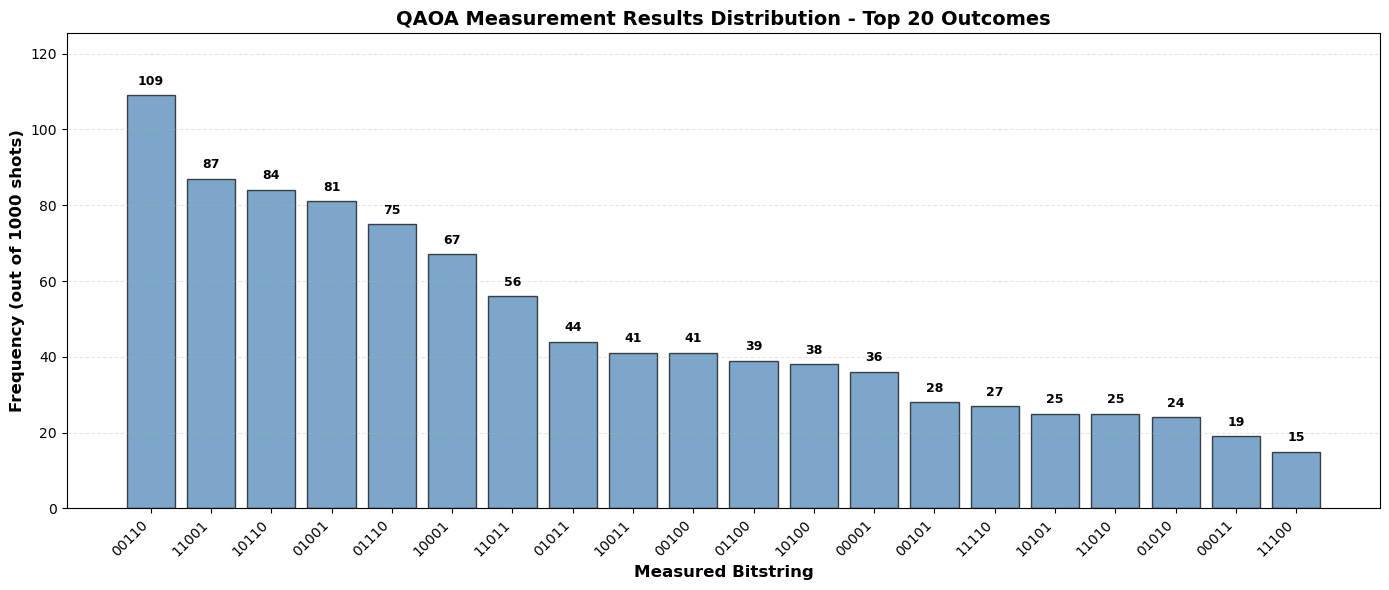

In [ ]:
# Set seed for reproducibility to ensure the same graph and same QAOA/RQAOA results
rnd.seed(seed)
np.random.seed(seed)

# Choose some graph problem
graph = nx.house_graph()
GraphUtils.add_random_weights(graph)
GraphUtils.normalize_weights(graph)

# Compute optimal partition using Brute-Force
optimal_partition = MaxCutBruteForce.solve(graph)
optimal_cost = GraphUtils.cost_func(graph, optimal_partition)

# Run QAOA (p=2, 1000 shots)
_, avg_estimated_cost_qaoa, counts_qaoa = run_qaoa_experiment(
    graph, qaoa_depth=2, qaoa_repetitions=1000
)

# run RQAOA (p=2, 1000 shots, target core size n_c=2)
_, estimated_cost_rqaoa = run_rqaoa_experiment(
    graph, qaoa_depth=2, qaoa_repetitions=1000, target_num_nodes=2
)

# plot graph
GraphUtils.plot_graph(graph)

# plot cut partition
GraphUtils.plot_cut(graph, optimal_partition)

# Print results
print('Brute-Force optimal partition:', optimal_partition)
print('Brute-Force optimal max cost:', optimal_cost)
print('QAOA estimated average max cost:', avg_estimated_cost_qaoa)
print('RQAOA estimated max cut cost:', estimated_cost_rqaoa)
print(f'Approximation ratio for QAOA: {avg_estimated_cost_qaoa / optimal_cost:.1%}')
print(f'Approximation ratio for RQAOA: {estimated_cost_rqaoa / optimal_cost:.1%}')

# Visualize the measurement distribution from 1000 shots
plt.figure(figsize=(12, 5))
GraphUtils.plot_qaoa_results(counts_qaoa, top_n=20)


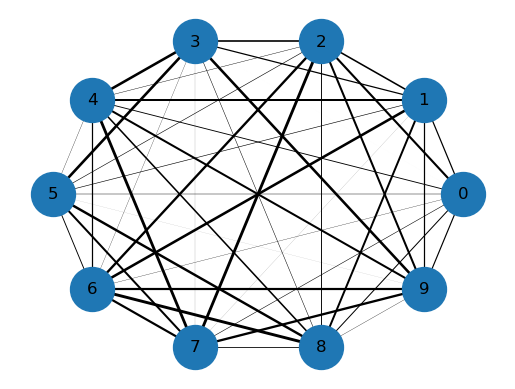

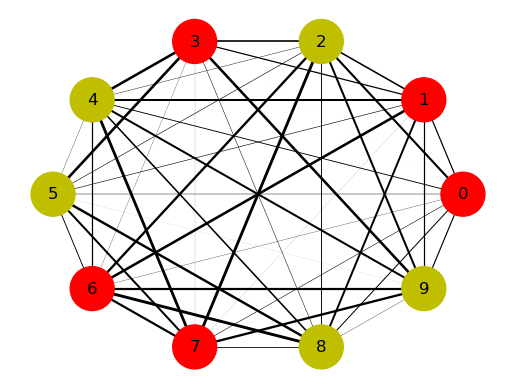


   Normal return from subroutine COBYLA

   NFVALS =   52   F =-1.109693E+01    MAXCV = 0.000000E+00
   X = 1.029442E+00   1.275051E+00  -4.989865E-01  -1.720753E-02

   Normal return from subroutine COBYLA

   NFVALS =   47   F =-1.136915E+01    MAXCV = 0.000000E+00
   X = 9.127409E-01  -6.775269E-03  -2.049135E-01  -2.085568E-01

   Normal return from subroutine COBYLA

   NFVALS =   56   F =-9.052945E+00    MAXCV = 0.000000E+00
   X = 2.206601E-01   1.945502E-01   2.389213E-01  -5.414737E-01

   Normal return from subroutine COBYLA

   NFVALS =   53   F =-7.056328E+00    MAXCV = 0.000000E+00
   X = 9.933780E-01  -2.533024E-01  -1.321577E-01  -2.261326E-01

   Normal return from subroutine COBYLA

   NFVALS =   53   F =-5.099699E+00    MAXCV = 0.000000E+00
   X = 1.008072E+00  -2.563396E-01  -2.613167E-01  -2.177135E-01

   Normal return from subroutine COBYLA

   NFVALS =   51   F =-3.203690E+00    MAXCV = 0.000000E+00
   X = 2.115573E-01   1.320265E+00  -1.647877E-01  -4.814696E-0

In [110]:
# Set seed for reproducibility to test on the exact same complete graph
rnd.seed(seed)
np.random.seed(seed)

# Choose some graph problem
graph_k10 = nx.complete_graph(10)
GraphUtils.add_random_weights(graph_k10)
GraphUtils.normalize_weights(graph_k10)

# Compute optimal partition using Brute-Force
optimal_partition_k10 = MaxCutBruteForce.solve(graph_k10)
optimal_cost_k10 = GraphUtils.cost_func(graph_k10, optimal_partition_k10)

# Visualize the graph
GraphUtils.plot_graph(graph_k10)

# plot cut partition
GraphUtils.plot_cut(graph_k10, optimal_partition_k10)

# Run QAOA (p=2, 1000 shots)
_, avg_estimated_cost_qaoa_k10, counts_qaoa_k10 = run_qaoa_experiment(
    graph_k10, qaoa_depth=2, qaoa_repetitions=1000
)

# Run RQAOA (p=2, 1000 shots, core size n_c=2)
_, estimated_cost_rqaoa_k10 = run_rqaoa_experiment(
    graph_k10, qaoa_depth=2, qaoa_repetitions=1000, target_num_nodes=2
)


# Print results
print('Brute-Force optimal partition:', optimal_partition_k10)
print('Brute-Force optimal max cost:', optimal_cost_k10)
print('QAOA estimated average max cost:', avg_estimated_cost_qaoa_k10)
print('RQAOA estimated max cut cost:', estimated_cost_rqaoa_k10)
print(f'Approximation ratio for QAOA: {avg_estimated_cost_qaoa_k10 / optimal_cost_k10:.1%}')
print(f'Approximation ratio for RQAOA: {estimated_cost_rqaoa_k10 / optimal_cost_k10:.1%}')


## Optional (takes a lot of time): Test for many graphs

* Provide an implementation of the RQAOA (i.e., the quantum version) for the Ising model problem as described in Figure 2 of the paper marked (*).
    * Run the depth-1 RQAOA on weighted graphs generated from various graph generator libraries like NetworkX and iGraph and report the approximation ratios.
    * Simulations should be done on randomly generated graphs (#nodes ≤ 20). Feel free to play around with the choice of optimizer for the QAOA parameters. To start with, we recommend using COBYLA for the optimizer. As a bonus, one can also compare the performance of RQAOA on the randomly generated graphs with different optimizers.

* Establish graphs to be studied:
    * We will study graphs with only 8, 12, or 16 nodes!

In [ ]:
rnd.seed(seed)
np.random.seed(seed)

# House graphs to be used only for illustrative purposes,
# and not for experiments!
HOUSE_GRAPHS = {
    'House': nx.house_graph(),
    'House-X': nx.house_x_graph(),
}

def ensure_connected(graph_gen_func, *params):
    """Generate a connected Erdos-Renyi graph"""
    for _ in range(1000):
        graph = graph_gen_func(*params)
        if nx.is_connected(graph):
            return graph
    raise TimeoutError('Could not generate connected graph')

ERDOS_RENYI_GRAPHS = {  # NOTE: graphs must be connected for RQAOA to work!
    f'Erdos-Renyi(n={n}, p={p})': ensure_connected(nx.erdos_renyi_graph, n, p)
    for n in [8, 12, 16]
    for p in [0.4, 0.6, 0.8]
}

RANDOM_REGULAR_GRAPHS = {
    f'{d}-Regular(n={n})': ensure_connected(nx.random_regular_graph, d, n)
    for d in [2, 3]
    for n in [8, 12, 16]
}

COMPLETE_GRAPHS = {
    f'Complete(n={n})': nx.complete_graph(n)
    for n in [8, 12, 16]
}

COMPLETE_BIPARTITE_GRAPHS = {
    f'Complete-Bipartite(n1={n}, n2={n})': nx.complete_multipartite_graph(n, n)
    for n in [4, 6, 8]
}

COMPLETE_TRIPARTITE_GRAPHS = {
    f'Complete-Tripartite(n1={n1}, n2={n2}, n3={n3})': nx.complete_multipartite_graph(n1, n2, n3)
    for n1, n2, n3 in [(2, 3, 3), (4, 4, 4), (5, 5, 6)]
}

def mapping(nrows, ncols):
    """Used for remapping nodes in Grid-2D graphs"""
    return dict(
        [(i, j), ncols * i + j]
        for i in range(nrows)
        for j in range(ncols)
    )

# Similar to general QPU layout
GRID_2D_GRAPHS = {
    f'Grid-2D(ncols={ncols}, nrows={nrows})': nx.relabel_nodes(nx.grid_graph(dim=(ncols, nrows)), mapping(nrows, ncols))
    for nrows, ncols in [(2, 4), (3, 4), (4, 4)]
}

PATH_GRAPHS = {
    f'Path(n={n})': nx.path_graph(n)
    for n in [8, 12, 16]
}

LADDER_GRAPHS = {
    f'Ladder(nrungs={n})': nx.ladder_graph(n)
    for n in [4, 6, 8]
}

CIRCULAR_LADDER_GRAPHS = {
    f'Circular-Ladder(nrungs={n})': nx.circular_ladder_graph(n)
    for n in [4, 6, 8]
}

STAR_GRAPHS = {
    f'Star({n})': nx.star_graph(n - 1)
    for n in [8, 12, 16]
}

ALL_GRAPHS = ERDOS_RENYI_GRAPHS \
           | RANDOM_REGULAR_GRAPHS \
           | COMPLETE_GRAPHS \
           | COMPLETE_BIPARTITE_GRAPHS \
           | COMPLETE_TRIPARTITE_GRAPHS \
           | GRID_2D_GRAPHS \
           | PATH_GRAPHS \
           | LADDER_GRAPHS \
           | CIRCULAR_LADDER_GRAPHS \
           | STAR_GRAPHS

* Print information on each graph being studied

In [112]:
for name in ALL_GRAPHS:
    print(name)

Erdos-Renyi(n=8, p=0.4)
Erdos-Renyi(n=8, p=0.6)
Erdos-Renyi(n=8, p=0.8)
Erdos-Renyi(n=12, p=0.4)
Erdos-Renyi(n=12, p=0.6)
Erdos-Renyi(n=12, p=0.8)
Erdos-Renyi(n=16, p=0.4)
Erdos-Renyi(n=16, p=0.6)
Erdos-Renyi(n=16, p=0.8)
2-Regular(n=8)
2-Regular(n=12)
2-Regular(n=16)
3-Regular(n=8)
3-Regular(n=12)
3-Regular(n=16)
Complete(n=8)
Complete(n=12)
Complete(n=16)
Complete-Bipartite(n1=4, n2=4)
Complete-Bipartite(n1=6, n2=6)
Complete-Bipartite(n1=8, n2=8)
Complete-Tripartite(n1=2, n2=3, n3=3)
Complete-Tripartite(n1=4, n2=4, n3=4)
Complete-Tripartite(n1=5, n2=5, n3=6)
Grid-2D(ncols=4, nrows=2)
Grid-2D(ncols=4, nrows=3)
Grid-2D(ncols=4, nrows=4)
Path(n=8)
Path(n=12)
Path(n=16)
Ladder(nrungs=4)
Ladder(nrungs=6)
Ladder(nrungs=8)
Circular-Ladder(nrungs=4)
Circular-Ladder(nrungs=6)
Circular-Ladder(nrungs=8)
Star(8)
Star(12)
Star(16)


* Perform experiments with QAOA:

In [113]:
# rnd.seed(seed)
# np.random.seed(seed)

# data = run_rqaoa_experiment_on_graphs(
#     graphs              = ALL_GRAPHS,
#     max_samples         = 10,
#     qaoa_depth          = 3,
#     qaoa_repetitions    = 1000,
#     target_num_nodes    = 4,
# )
# data